In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib

In [2]:
#f = open("./perun_results/main_2025-03-19T07:17:21.723178.txt", "r")
f = open("./perun_results/db_res.txt", "r")
content = f.read()

In [6]:
monitored_function_contents =  content.split("\n")[16:]

def process_avg_value(entry):
    entries = entry.split(" ± ")
    avg_entry = float(entries[0].strip())
    std_entry = float(entries[1][:-3].strip())
    return avg_entry, std_entry

def parse_function_name(function_name):
    function_name_contents = function_name.split("_")
    db = function_name_contents[0]
    approach = function_name_contents[1]
    operation = ""
    if "read" in function_name_contents or "update" in function_name_contents:
        operation = "_".join(function_name_contents[-2:])
    else:
        operation = function_name_contents[-1]
    dataset_name = ""
    if "ppi" in function_name:
        dataset_name = "ppi"
    else:
        dataset_name = "_".join(function_name_contents[2:4])
    return db, approach, operation, dataset_name

def process_line(line):
    line_contents = line.split("|")
    function_name  = line_contents[2].strip()
    db, approach, operation, dataset_name = parse_function_name(function_name)
    num_calls = int(line_contents[3].strip())
    avg_run_time, std_run_time = process_avg_value(line_contents[4])
    avg_cpu_util, std_cpu_util = process_avg_value(line_contents[5])
    avg_mem_util, std_mem_util = process_avg_value(line_contents[6])
    # avg_power, std_power = process_avg_value(line_contents[7])
    # avg_gpu_util, std_gpu_util = process_avg_value(line_contents[8])

    # avg_energy = (avg_run_time / 3600) * avg_power #/1000
    
    #std_energy =  avg_power*(avg_run_time / 3600)* math.sqrt((std_power/avg_power)**2 + ((std_run_time / 3600) / (avg_run_time / 3600))**2) # /1000
    return {
        "db": db,
        "approach":approach,
        "operation": operation,
        "dataset_name": dataset_name,
        "function_name": function_name,
        "num_calls": num_calls,
        "avg_run_time": avg_run_time,
        "std_run_time": std_run_time,
        "avg_cpu_util": avg_cpu_util,
        "std_cpu_util": std_cpu_util,
        "avg_mem_util": avg_mem_util,
        "std_mem_util": std_mem_util,
        # "avg_power": avg_power,
        # "std_power": std_power,
        # "avg_gpu_util": avg_gpu_util,
        # "std_gpu_util": std_gpu_util,
        # "avg_energy": avg_energy,
        # "std_energy": std_energy
    }

row_information_list = []
for i, line in enumerate(monitored_function_contents):
    if len(line.strip()) == 0: break
    if i < 2: continue
    row_information = process_line(line)
    row_information_list.append(row_information)    

In [7]:
def get_approach_df(approach):
    df = pd.DataFrame(row_information_list)
    filtered_df = df[df["approach"] == approach]
    return filtered_df

In [8]:
def get_operation_df(df, operation):
    filtered_df = df[df["operation"] == operation]
    return filtered_df

def sort_df(df):
    df["dataset_name"] = df["dataset_name"].str.replace("_", "N_").str.replace("5", "5E").str.replace("_10", "_10E").str.replace("20", "20E")#.str.replace("SF", "9SF")
    ## relabel trick for easy sorting
    for key in relabel_dict:
        df["dataset_name"] = df["dataset_name"].str.replace(key, relabel_dict[key])
    df = df.sort_values(by=["dataset_name"], ascending=False)
    for key in rev_relabel_dict:
        df["dataset_name"] = df["dataset_name"].str.replace(key, rev_relabel_dict[key])
    return df

In [25]:
import matplotlib 

font = {'family': 'arial',
        'weight': 'normal',
        'size': 25}

db_colors = {
    "neo4j": "blue",
    "postgres": "orange",
    "mysql": "red",
    "in_mem": "black",
    "sqlite": "purple",
    "list_json": "purple"
}


db_label_dict = {
    "mysql": "MySQL",
    "postgres": "PostgreSQL",
    "neo4j": "Neo4j",
    "in mem": "In-memory",
    "sqlite": "SQLite",
    "list_json":"SQLite"
}
relabel_dict = {
    "5E": "D",
    "10E": "C",
    "20E": "B",
    "SF": "A",
}

metric_to_unit = {
    "run_time": "Time [s]",
    'cpu_util': "Utilization [%]", 'mem_util': "Utilization [GB]", 'power': "Power [W]", 'energy': "Energy [Wh]"
}
rev_relabel_dict = {relabel_dict[key]: key for key in relabel_dict}
matplotlib.rc('font', **font)

In [30]:
def plot(approach, operations, metric = "run_time"):
    """
    approach: Union["col", "list"]
    operations: list['update_nodes', 'create', 'delete', 'read_1', 'read_2', 'read_3',
       'update_edges']
    metric: Union['run_time', 'cpu_util', 'mem_util', 'power', 'energy']
    """
    assert approach in ["col", "list"], "Approach must either be 'col' or 'list'"
    assert metric in ['run_time', 'cpu_util', 'mem_util', 'power', 'energy'], "Not a valid metric - Choose from ['run_time', 'cpu_util', 'mem_util', 'power', 'energy']"
    df = get_approach_df(approach)
    df = sort_df(df)
    n_subplots = len(operations)
    fig, axes = plt.subplots(n_subplots, figsize=(30, 8 * n_subplots))
    for i, operation in enumerate(operations):
        filtered_df = get_operation_df(df, operation)
        ax = axes[i]
        ax.set_title(operation.title().replace("_", " ") + f" ({approach})")
        legend_entries = {}  # Dictionary to track unique legend entries
        for i, (group_name, group_data) in enumerate(filtered_df.groupby("db")):
            color_key = list(filter(lambda k: k in group_name, db_colors))[0]
            color = db_colors[color_key]
            db_label = group_name
            if db_label not in legend_entries:
                db_label = db_label_dict[db_label]
                legend_entries[db_label] = color
            num_cols = 3#len(group_data.columns)
            x = np.arange(len(group_data))
            width = .6 / num_cols
            ax.bar(x + i * width, group_data[f"avg_{metric}"], width=width, color=color, yerr = group_data[f"std_{metric}"])
            
            ax.set_xticks(x + width * (num_cols / 2 - 0.5))
        
            def process_dataset_label(label: str):
                return label.replace("_", " ").replace("1000000", "1Mio.")[::-1].replace("000", "K")[::-1]
            dataset_label = list(map(process_dataset_label, group_data["dataset_name"]))
            
            ax.set_xticklabels(dataset_label)
            sec = ax.secondary_xaxis('bottom')
            sec.set_xticks([.25, 2.75, 6.75, 10.75, 13.75],
                           labels=['\n\nReal-world', '\n\nSmall', '\n\nMedium', '\n\nLarge', '\n\nLargest'])
            sec.tick_params(axis='x', length=0)
            sec2 = ax.secondary_xaxis('bottom')
            sec2.set_xticks([-.25, .75, 4.75, 8.75, 12.85, 14.75], labels=[])
            sec2.tick_params(axis='x', length=40, width=1.5)
        handles = [plt.Rectangle((0, 0), 1, 1, color=color, label=label)
                       for label, color in legend_entries.items()]
        fig.legend(handles=handles, loc='lower center', ncol=((len(handles)+1)),
                   bbox_to_anchor=(0.55, 1))
        ax.grid(which="both", axis="y")
        ax.grid(which="major", axis="x")
        ax.set_ylabel(metric_to_unit[metric])
        ax.set_yscale('log')
        ax.set_xlim([-0.25, 14.75])
        plt.tight_layout(h_pad = 1.5)
        plt.subplots_adjust(bottom=0.18)


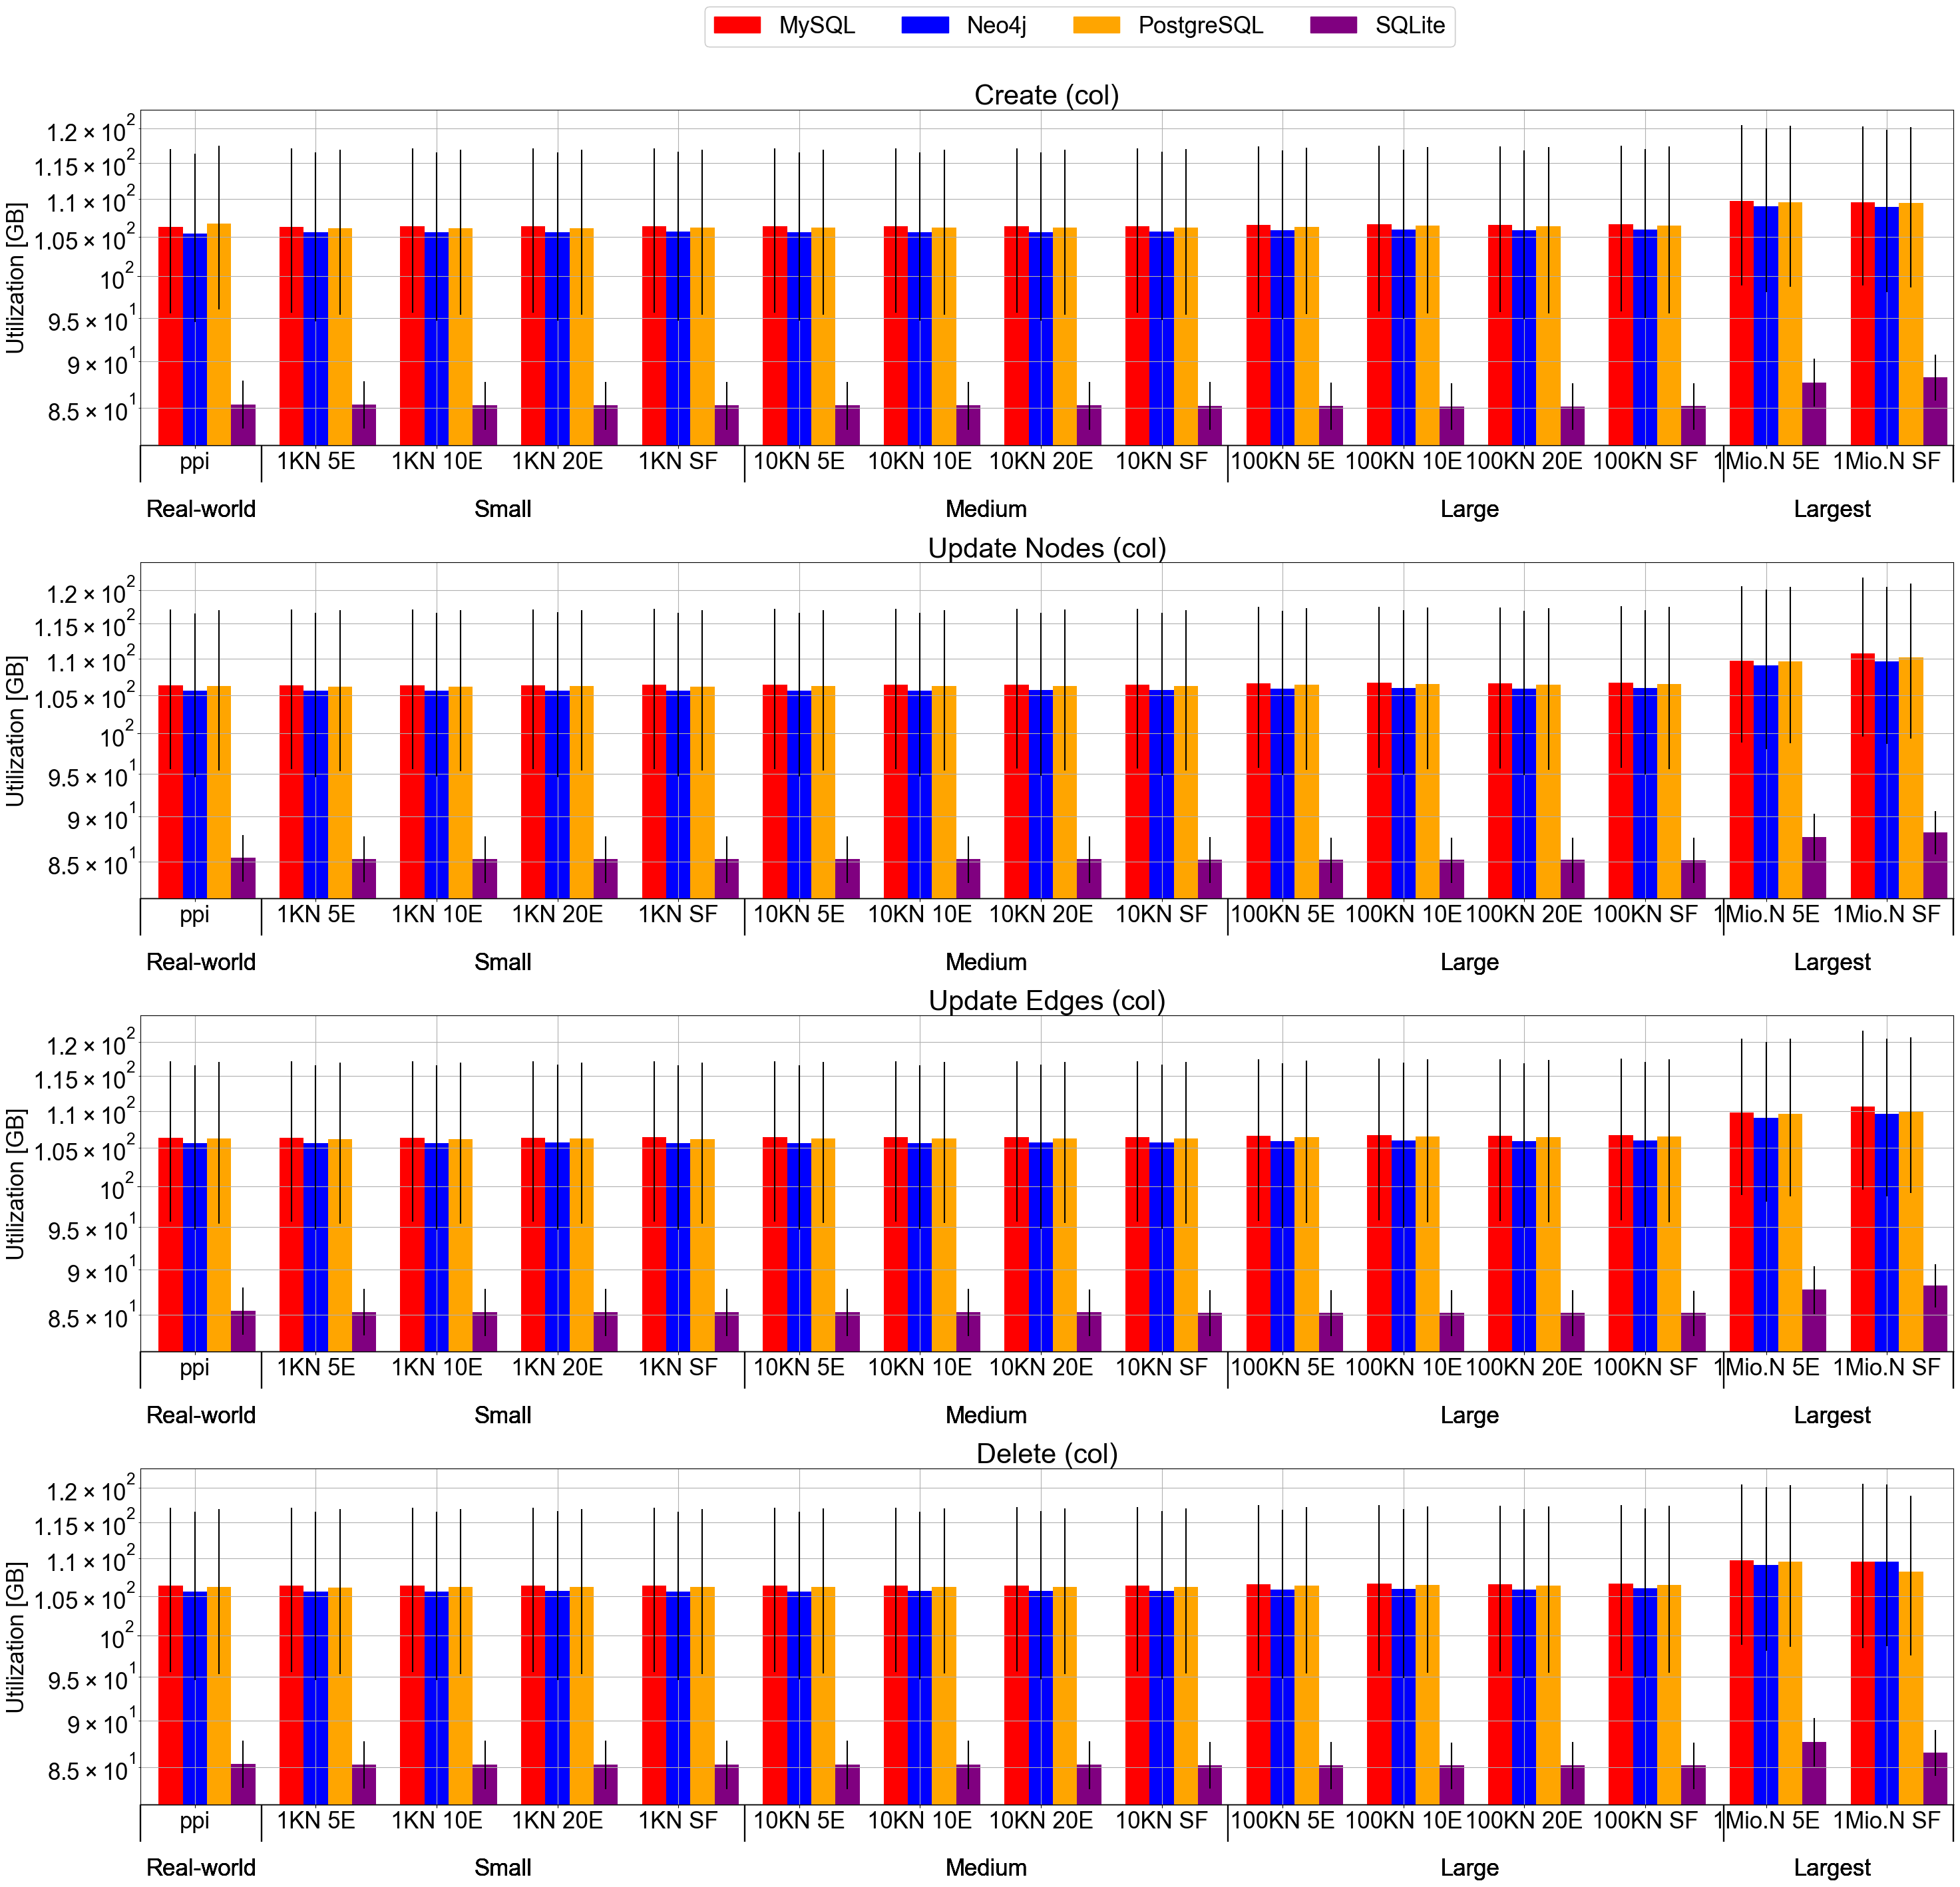

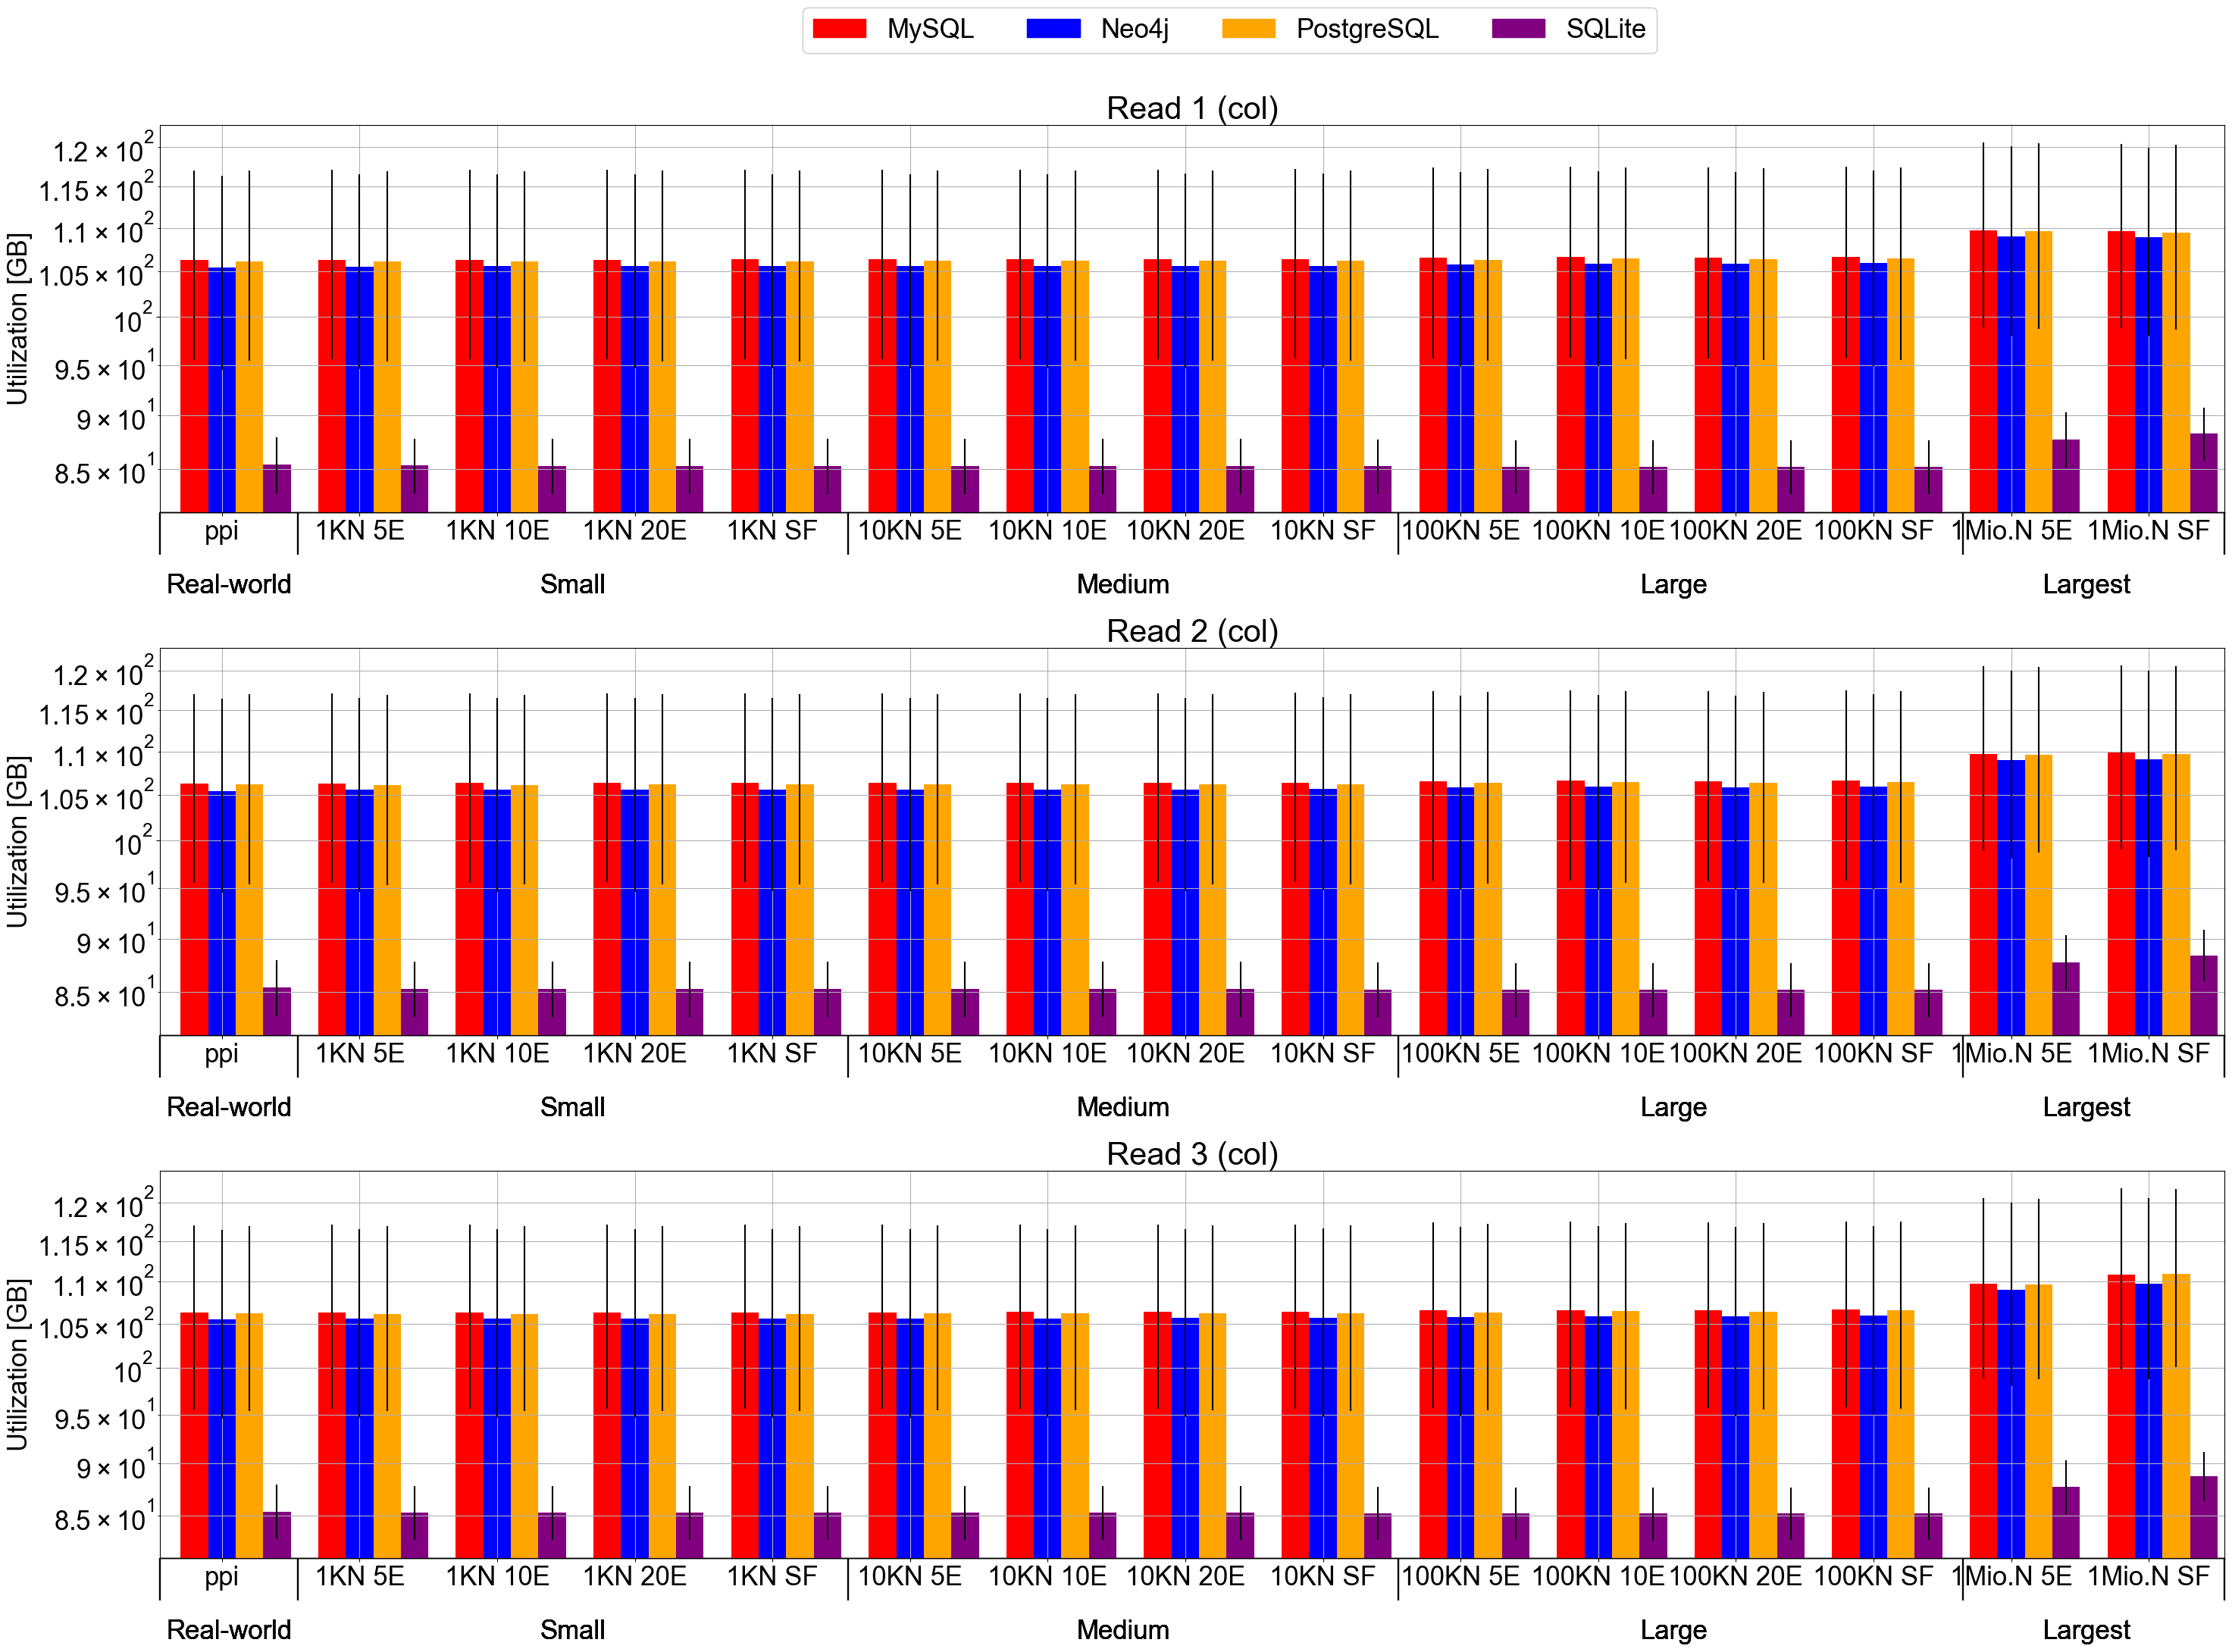

In [33]:
metric = "mem_util" #"energy"
approach = "col"
plot(approach, ["create", "update_nodes", "update_edges", "delete"], metric=metric)
plot(approach, ['read_1', 'read_2', 'read_3'], metric=metric)